<a href="https://colab.research.google.com/github/Eddydev-ALU/Malaria_Diagnosis_Models/blob/main/Member4_ResNet50_Malaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Member 4 — Transfer Learning with **ResNet50** (+ Fine-Tuning)
### Malaria Diagnosis — Formative 2 (Group 6)

**Owner:** Enock Mugisha &nbsp;|&nbsp; **Model:** ResNet50 (ImageNet → malaria cell images)

This section trains and evaluates a ResNet50 transfer-learning model on the NIH malaria
cell-image dataset. It covers the full required pipeline:

1. A stratified **70 / 15 / 15** train / validation / test split built with the **`tf.data` API**.
2. A reusable **Functional-API** model builder: frozen ResNet50 backbone + custom classifier head, with the correct `resnet50.preprocess_input`.
3. **Seven systematic experiments** moving from feature extraction → regularisation → learning-rate study → progressive fine-tuning → final tuned model.
4. A consolidated **results table** (accuracy, precision, recall, F1, AUC).
5. **Visual analysis**: learning curves, confusion matrix, and ROC / AUC for the best model.
6. **Error analysis** and an over/under-fitting discussion.

> **How to run:** open in Google Colab → `Runtime ▸ Change runtime type ▸ GPU (T4)` → run the cells in order. The data-download cell from the group notebook (`cell_images.zip`) must have run first, or run the small download cell included below.


## 0. Setup & reproducibility

In [1]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)

# Reproducibility -------------------------------------------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Global config ---------------------------------------------------------------
IMG_SIZE   = 224          # ResNet50 default input size
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE
CLASS_NAMES = ["Uninfected", "Parasitized"]   # label 0 = Uninfected, 1 = Parasitized (positive)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data — locate dataset, stratified split, `tf.data` pipeline

The NIH dataset has two folders: `Parasitized/` and `Uninfected/`. We define
**Parasitized = positive class (label 1)** because, in a screening tool, the clinically
important event is *detecting* an infected cell — so **recall on the Parasitized class is
our sensitivity**.

If the group download cell has not run yet, the next cell will fetch the data.

In [2]:
# --- Make sure the data exists (skip if the group's download cell already ran) ---
if not (os.path.isdir("cell_images/Parasitized") or os.path.isdir("cell_images/cell_images/Parasitized")):
    print("Downloading NIH malaria dataset ...")
    !wget -q https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip -q cell_images.zip
    print("Done.")
else:
    print("Dataset already present.")

Done.


In [3]:
# --- Auto-detect the folder that contains Parasitized/ and Uninfected/ ---
candidates = ["cell_images", "cell_images/cell_images", "./train", "."]
CELL_DIR = None
for c in candidates:
    if os.path.isdir(os.path.join(c, "Parasitized")) and os.path.isdir(os.path.join(c, "Uninfected")):
        CELL_DIR = c
        break
assert CELL_DIR is not None, "Could not find Parasitized/Uninfected folders."
print("Using data directory:", CELL_DIR)

# --- Gather all (filepath, label) pairs ---
paths, labels = [], []
for label_idx, cls in enumerate(CLASS_NAMES):          # 0=Uninfected, 1=Parasitized
    folder = os.path.join(CELL_DIR, cls)
    for f in os.listdir(folder):
        if f.lower().endswith(".png"):                 # ignore Thumbs.db etc.
            paths.append(os.path.join(folder, f))
            labels.append(label_idx)

paths  = np.array(paths)
labels = np.array(labels)
print(f"Total images: {len(paths)}  |  "
      f"Parasitized: {(labels==1).sum()}  Uninfected: {(labels==0).sum()}")

Using data directory: cell_images
Total images: 27558  |  Parasitized: 13779  Uninfected: 13779


In [4]:
# --- Stratified 70 / 15 / 15 split (train / val / test) ---
p_train, p_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
p_val, p_test, y_val, y_test = train_test_split(
    p_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train: {len(p_train)}   Val: {len(p_val)}   Test: {len(p_test)}")

# --- tf.data loading function: read -> decode -> resize -> float32 [0,255] ---
# NOTE: we keep pixels in [0,255] here. preprocess_input is applied INSIDE the
# model so that augmentation operates on raw pixels first.
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.float32)

def make_ds(p, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(p), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(p_train, y_train, shuffle=True)
val_ds   = make_ds(p_val,   y_val)
test_ds  = make_ds(p_test,  y_test)

# Class weights (data is nearly balanced, but we keep this for completeness)
n0, n1 = (y_train==0).sum(), (y_train==1).sum()
total = n0 + n1
class_weight = {0: total/(2*n0), 1: total/(2*n1)}
print("Class weights:", class_weight)

Train: 19290   Val: 4134   Test: 4134
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


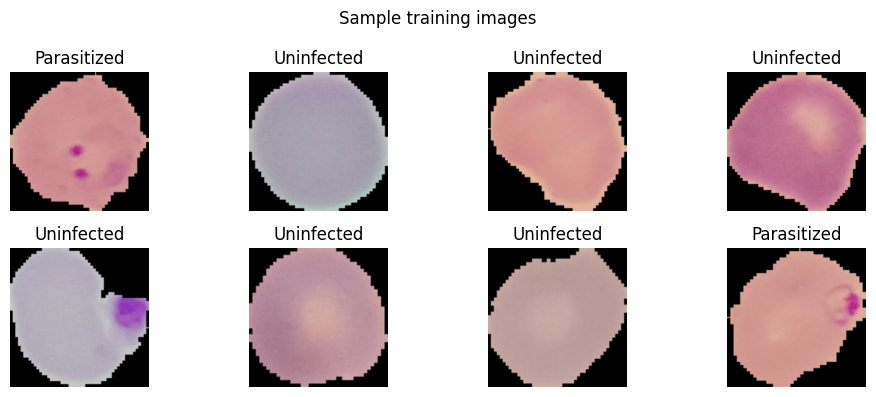

In [5]:
# --- Quick visual sanity check of one batch ---
imgs, lbls = next(iter(train_ds))
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(imgs[i].numpy().astype("uint8"))
    plt.title(CLASS_NAMES[int(lbls[i])]); plt.axis("off")
plt.suptitle("Sample training images"); plt.tight_layout(); plt.show()

## 2. Model builder (Functional API)

The model is built with the **Functional API** so the pipeline is explicit:

`Input → (data augmentation, training only) → resnet50.preprocess_input → ResNet50 base → GlobalAveragePooling → Dropout → Dense(1, sigmoid)`

Two important transfer-learning details that we discuss in the report:

* **`preprocess_input`** must be ResNet's own (it converts RGB→BGR and subtracts ImageNet
  channel means). Using a plain `/255` rescale here *silently hurts* ResNet accuracy.
* When **fine-tuning**, we unfreeze the top layers **but keep all `BatchNormalization`
  layers frozen**. Their ImageNet running statistics should not be disturbed by our small
  medical batches.

In [7]:
# Data-augmentation block (only active during training)
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
], name="data_augmentation")


def build_model(augment=False, dropout=0.0, unfreeze_last_n=0):
    """Build a ResNet50 transfer-learning model.

    augment          : add the augmentation block (data strategy)
    dropout          : dropout rate before the final Dense (regularisation)
    unfreeze_last_n  : 0 -> pure feature extraction (whole base frozen).
                       >0 -> fine-tune the last N base layers (BatchNorm stays frozen).
    """
    base = ResNet50(include_top=False, weights="imagenet",
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))

    if unfreeze_last_n == 0:
        base.trainable = False                         # feature extraction
    else:
        base.trainable = True
        for layer in base.layers[:-unfreeze_last_n]:   # freeze everything except top N
            layer.trainable = False
        for layer in base.layers:                      # always keep BatchNorm frozen
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs) if augment else inputs
    x = preprocess_input(x)                             # ResNet-specific preprocessing
    x = base(x, training=False)                         # BN in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inputs, outputs, name="resnet50_transfer")


def make_optimizer(name, lr):
    return optimizers.SGD(lr, momentum=0.9) if name == "sgd" else optimizers.Adam(lr)

## 3. Reusable training & evaluation utilities

`run_experiment` trains one configuration, evaluates it on the **test set**, and returns a
tidy metrics dictionary plus the data needed for plots. Keeping this as one function makes
the seven experiments reproducible and the notebook modular (and easy to defend orally).

In [8]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),       # = sensitivity for Parasitized
        "f1":        f1_score(y_true, y_pred),
        "auc":       roc_auc_score(y_true, y_prob),
    }


def run_experiment(cfg, train_ds, val_ds, test_ds, verbose=1):
    """Train + evaluate one experiment config. Returns a results dict."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_model(augment=cfg["augment"],
                        dropout=cfg["dropout"],
                        unfreeze_last_n=cfg["unfreeze_last_n"])
    model.compile(optimizer=make_optimizer(cfg["optimizer"], cfg["lr"]),
                  loss="binary_crossentropy", metrics=["accuracy"])

    cbs = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=2, min_lr=1e-7),
    ]

    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=cfg["epochs"], class_weight=class_weight,
                        callbacks=cbs, verbose=verbose)
    train_time = time.time() - t0

    # --- Evaluate on the held-out test set ---
    y_prob = model.predict(test_ds, verbose=0).ravel()
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
    metrics = compute_metrics(y_true, y_prob)

    result = {
        "name": cfg["name"], **cfg, **metrics,
        "epochs_ran": len(history.history["loss"]),
        "train_time_s": round(train_time, 1),
        "history": history.history,
        "y_true": y_true, "y_prob": y_prob,
    }
    del model
    print(f"  -> {cfg['name']}: acc={metrics['accuracy']:.4f}  "
          f"f1={metrics['f1']:.4f}  auc={metrics['auc']:.4f}")
    return result

In [9]:
# ---- Plotting helpers ----
def plot_history(history, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history["loss"], label="train")
    ax[0].plot(history["val_loss"], label="val")
    ax[0].set_title(f"Loss — {title}"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(history["accuracy"], label="train")
    ax[1].plot(history["val_accuracy"], label="val")
    ax[1].set_title(f"Accuracy — {title}"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()


def plot_confusion(y_true, y_prob, title=""):
    cm = confusion_matrix(y_true, (y_prob >= 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {title}"); plt.show()
    return cm


def plot_roc(y_true, y_prob, title=""):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"ResNet50 (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="chance")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {title}"); plt.legend(); plt.show()

## 4. Experiment matrix — 7 systematic experiments

Each experiment changes **one main factor** so its effect is interpretable. This is the
story the report tells: *what helps ResNet50 on malaria cells, and why.*

| # | Name | What changes | Strategy |
|---|------|--------------|----------|
| 1 | `E1_FE_baseline` | frozen base, Adam 1e-3, no aug, no dropout | feature extraction baseline |
| 2 | `E2_FE_augment`  | + data augmentation | data strategy |
| 3 | `E3_FE_aug_drop` | + dropout 0.5 | regularisation |
| 4 | `E4_FE_lowLR`    | lower LR 1e-4 | learning-rate study |
| 5 | `E5_FT_top30`    | fine-tune last 30 layers, LR 1e-5 | shallow fine-tuning |
| 6 | `E6_FT_top60`    | fine-tune last 60 layers, LR 1e-5 | deeper fine-tuning |
| 7 | `E7_FT_sgd_best` | best fine-tune, SGD+momentum, LR 1e-4 | final tuned model |

> **Runtime note:** on a Colab **T4 GPU** the full set takes roughly **1–2 hours**.
> To prototype fast, set `QUICK_TEST = True` below — it trims epochs so you can confirm
> everything runs, then switch back to `False` for the real numbers you put in the report.

In [13]:
QUICK_TEST = False   # True = tiny epochs just to verify the pipeline runs

def E(name, augment, dropout, lr, unfreeze_last_n, optimizer, epochs):
    return dict(name=name, augment=augment, dropout=dropout, lr=lr,
                unfreeze_last_n=unfreeze_last_n, optimizer=optimizer,
                epochs=2 if QUICK_TEST else epochs)

EXPERIMENTS = [
    E("E1_FE_baseline", False, 0.0, 1e-3, 0,  "adam", 12),
    E("E2_FE_augment",  True,  0.0, 1e-3, 0,  "adam", 12),
    E("E3_FE_aug_drop", True,  0.5, 1e-3, 0,  "adam", 12),
    E("E4_FE_lowLR",    True,  0.5, 1e-4, 0,  "adam", 15),
    E("E5_FT_top30",    True,  0.5, 1e-5, 30, "adam", 10),
    E("E6_FT_top60",    True,  0.5, 1e-5, 60, "adam", 10),
    E("E7_FT_sgd_best", True,  0.4, 1e-4, 30, "sgd",  12),
]
for e in EXPERIMENTS:
    print(e["name"], "->", {k: e[k] for k in ["augment","dropout","lr","unfreeze_last_n","optimizer","epochs"]})

E1_FE_baseline -> {'augment': False, 'dropout': 0.0, 'lr': 0.001, 'unfreeze_last_n': 0, 'optimizer': 'adam', 'epochs': 12}
E2_FE_augment -> {'augment': True, 'dropout': 0.0, 'lr': 0.001, 'unfreeze_last_n': 0, 'optimizer': 'adam', 'epochs': 12}
E3_FE_aug_drop -> {'augment': True, 'dropout': 0.5, 'lr': 0.001, 'unfreeze_last_n': 0, 'optimizer': 'adam', 'epochs': 12}
E4_FE_lowLR -> {'augment': True, 'dropout': 0.5, 'lr': 0.0001, 'unfreeze_last_n': 0, 'optimizer': 'adam', 'epochs': 15}
E5_FT_top30 -> {'augment': True, 'dropout': 0.5, 'lr': 1e-05, 'unfreeze_last_n': 30, 'optimizer': 'adam', 'epochs': 10}
E6_FT_top60 -> {'augment': True, 'dropout': 0.5, 'lr': 1e-05, 'unfreeze_last_n': 60, 'optimizer': 'adam', 'epochs': 10}
E7_FT_sgd_best -> {'augment': True, 'dropout': 0.4, 'lr': 0.0001, 'unfreeze_last_n': 30, 'optimizer': 'sgd', 'epochs': 12}


In [14]:
# --- Run all seven experiments (results accumulate in `results`) ---
# Tip: you can also run them one at a time by indexing EXPERIMENTS[i] if a session
# disconnects — just append to `results`.
results = []
for cfg in EXPERIMENTS:
    print(f"\n=== Training {cfg['name']} ===")
    results.append(run_experiment(cfg, train_ds, val_ds, test_ds, verbose=1))


=== Training E1_FE_baseline ===
Epoch 1/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 74s 108ms/step - accuracy: 0.8934 - loss: 0.2576 - val_accuracy: 0.9095 - val_loss: 0.2243 - learning_rate: 0.0010
Epoch 2/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 58s 96ms/step - accuracy: 0.9307 - loss: 0.1876 - val_accuracy: 0.9325 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 3/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 59s 98ms/step - accuracy: 0.9377 - loss: 0.1729 - val_accuracy: 0.9386 - val_loss: 0.1721 - learning_rate: 0.0010
Epoch 4/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 63s 104ms/step - accuracy: 0.9422 - loss: 0.1600 - val_accuracy: 0.9415 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 5/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 79s 99ms/step - accuracy: 0.9454 - loss: 0.1511 - val_accuracy: 0.9393 - val_loss: 0.1651 - learning_rate: 0.0010
Epoch 6/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - accuracy: 0.9473 - loss: 0.1493 - val_accuracy: 0.9439 - val_loss: 0.1601 - learning_rate: 0.0010
Epoch 7/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 

## 5. Consolidated results table

In [15]:
summary = pd.DataFrame([{
    "Experiment":  r["name"],
    "Augment":     r["augment"],
    "Dropout":     r["dropout"],
    "LR":          r["lr"],
    "Unfrozen":    r["unfreeze_last_n"],
    "Optimizer":   r["optimizer"],
    "Epochs":      r["epochs_ran"],
    "Accuracy":    round(r["accuracy"], 4),
    "Precision":   round(r["precision"], 4),
    "Recall":      round(r["recall"], 4),
    "F1":          round(r["f1"], 4),
    "AUC":         round(r["auc"], 4),
    "Time (s)":    r["train_time_s"],
} for r in results])

summary = summary.sort_values("F1", ascending=False).reset_index(drop=True)
display(summary)

# Save for the report
summary.to_csv("resnet50_results.csv", index=False)
print("\nBest by F1:", summary.iloc[0]["Experiment"])

,Experiment,Augment,Dropout,LR,Unfrozen,Optimizer,Epochs,Accuracy,Precision,Recall,F1,AUC,Time (s)
0,E6_FT_top60,True,0.5,0.00001,60,adam,10,0.9661,0.9711,0.9608,0.9660,0.9942,1403.8
1,E5_FT_top30,True,0.5,0.00001,30,adam,10,0.9620,0.9668,0.9569,0.9618,0.9931,1260.3
2,E7_FT_sgd_best,True,0.4,0.00010,30,sgd,12,0.9586,0.9740,0.9424,0.9580,0.9914,1449.7
3,E1_FE_baseline,False,0.0,0.00100,0,adam,12,0.9499,0.9545,0.9448,0.9497,0.9864,781.6
4,E2_FE_augment,True,0.0,0.00100,0,adam,12,0.9400,0.9491,0.9299,0.9394,0.9836,1218.2
5,E4_FE_lowLR,True,0.5,0.00010,0,adam,15,0.9090,0.9397,0.8742,0.9058,0.9711,1605.1
6,E3_FE_aug_drop,True,0.5,0.00100,0,adam,8,0.9095,0.9510,0.8636,0.9052,0.9753,814.5



Best by F1: E6_FT_top60


## 6. Visual analysis

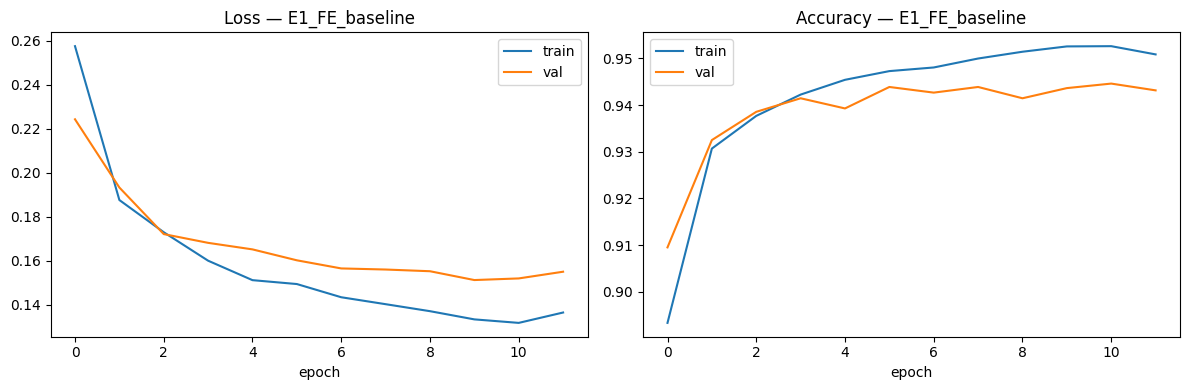

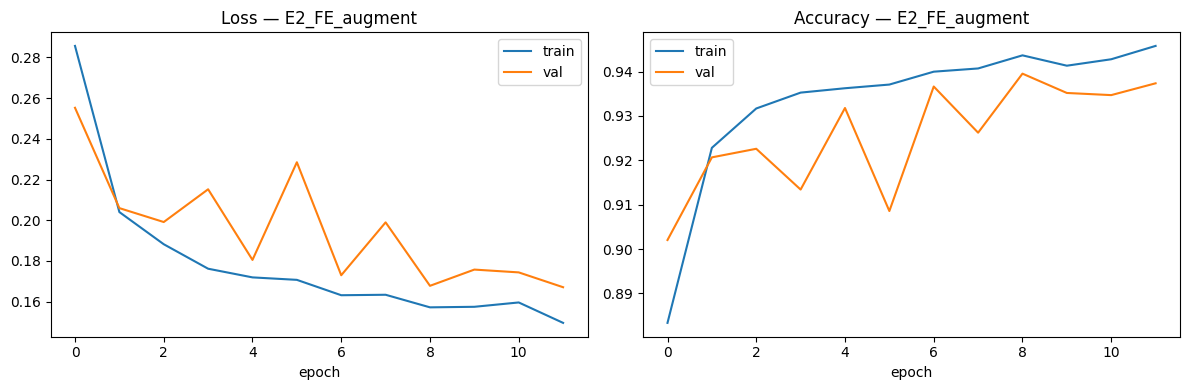

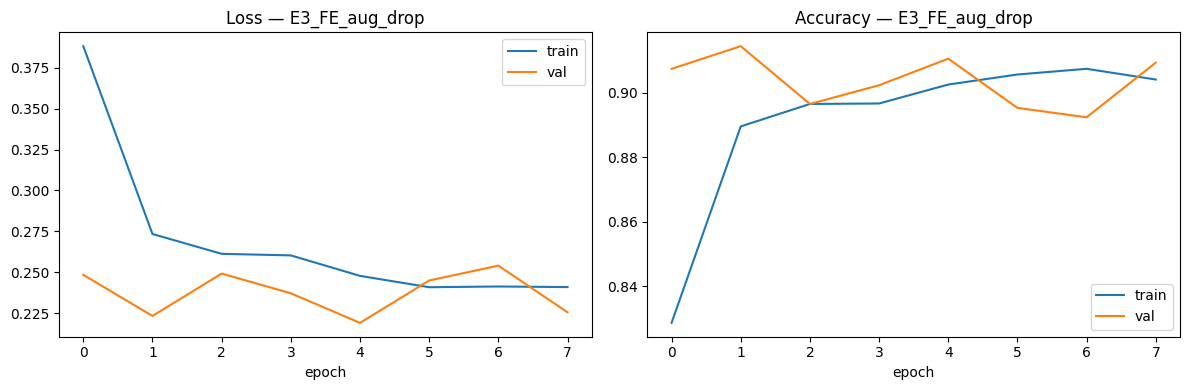

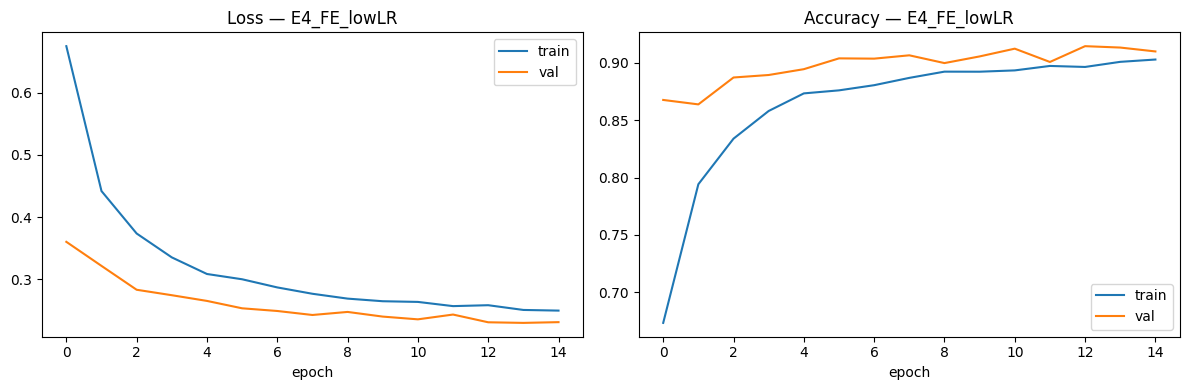

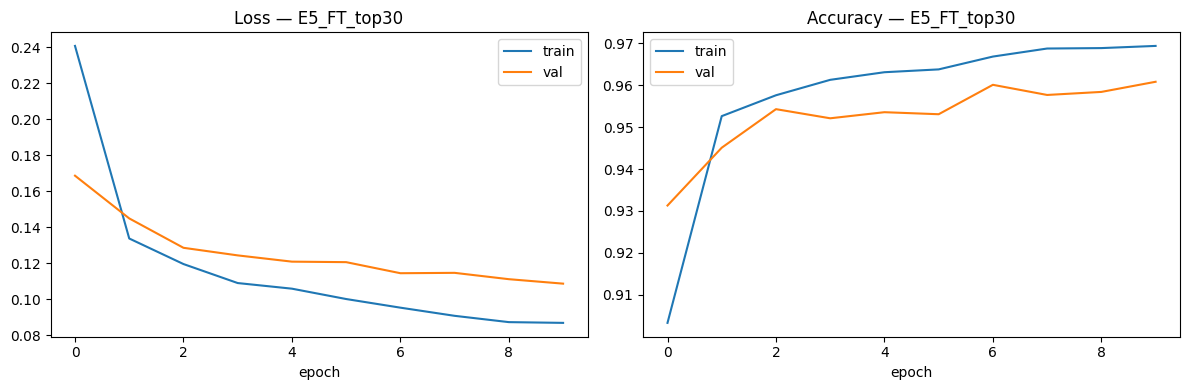

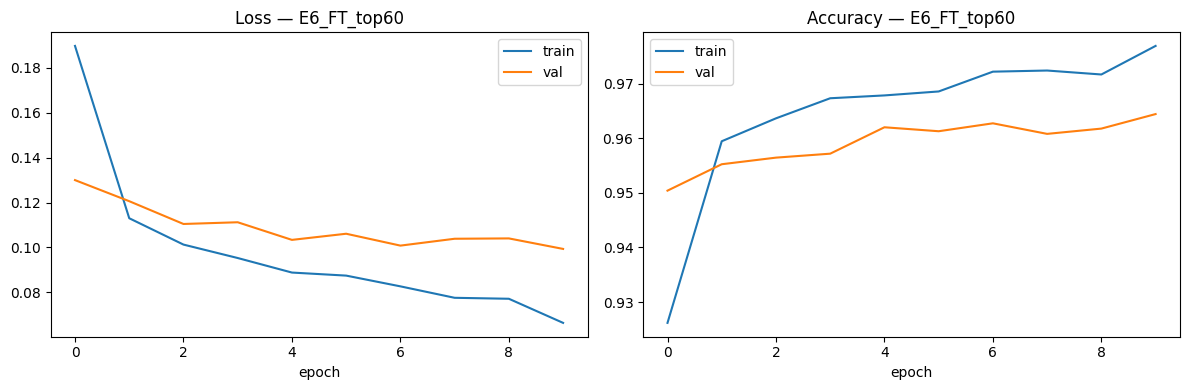

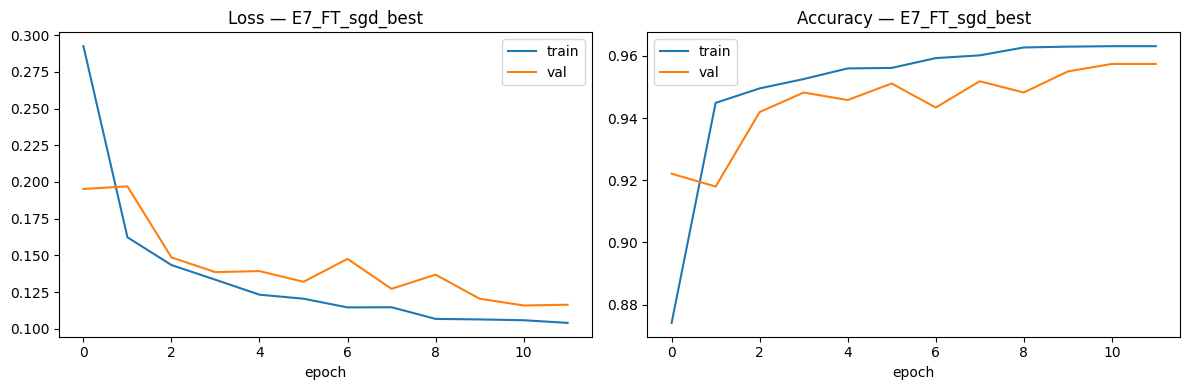

In [16]:
# 6a. Learning curves for every experiment
for r in results:
    plot_history(r["history"], title=r["name"])

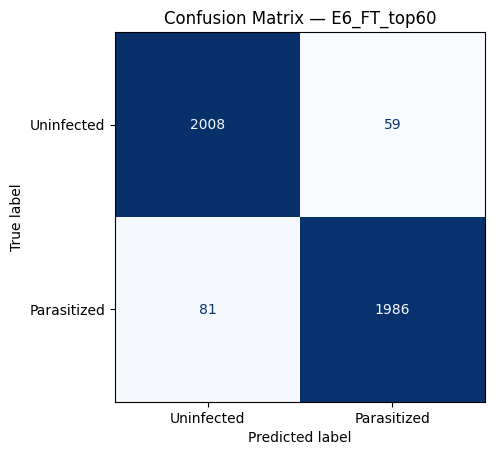

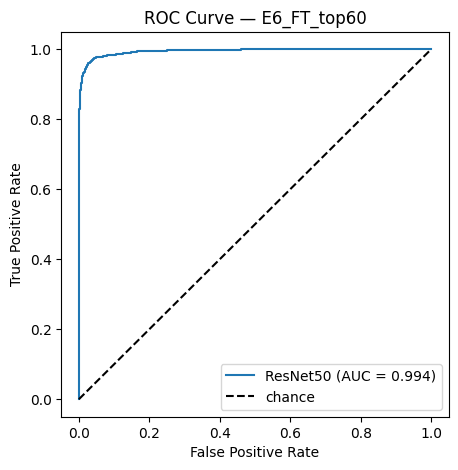

Best model: E6_FT_top60
  True Positives (parasitized caught): 1986
  False Negatives (missed infections): 81  <-- most clinically costly
  False Positives (false alarms):      59
  Sensitivity/Recall: 0.9608   Specificity: 0.9715


In [17]:
# 6b. Confusion matrix + ROC/AUC for the BEST model (highest F1)
best_name = summary.iloc[0]["Experiment"]
best = next(r for r in results if r["name"] == best_name)

cm = plot_confusion(best["y_true"], best["y_prob"], title=best_name)
plot_roc(best["y_true"], best["y_prob"], title=best_name)

tn, fp, fn, tp = cm.ravel()
print(f"Best model: {best_name}")
print(f"  True Positives (parasitized caught): {tp}")
print(f"  False Negatives (missed infections): {fn}  <-- most clinically costly")
print(f"  False Positives (false alarms):      {fp}")
print(f"  Sensitivity/Recall: {tp/(tp+fn):.4f}   Specificity: {tn/(tn+fp):.4f}")

## 7. Error analysis & over/under-fitting discussion

> **Write this from YOUR actual numbers** once the experiments finish. The prompts below
> map directly to the rubric ("error analysis", "symptoms of over/under-fitting and how it
> was handled"). Replace each `[...]` with what you observed.

**Feature extraction (E1–E4).** Compare train vs. validation curves. If train accuracy
climbs while validation plateaus or worsens, that is **overfitting**; note whether adding
augmentation (E2) and dropout (E3) narrowed that gap. If *both* train and val accuracy stay
low and flat, that is **underfitting** — likely the head can't learn enough or the LR is off
(compare E1 vs E4). State which one you saw: `[overfitting / underfitting]` and the evidence.

**Fine-tuning (E5–E7).** Unfreezing top layers usually lifts AUC but risks overfitting on a
medical dataset; the very low LR (1e-5) and frozen BatchNorm layers were the controls used.
Did deeper fine-tuning (E6) help or hurt vs. shallow (E5)? `[...]`

**Misclassifications.** From the confusion matrix, **false negatives** (missed parasitised
cells) are the most dangerous in a screening context. Report the FN count, look at a few of
those images, and comment on likely causes (faint/early-stage parasites, staining/lighting
variation, blur). `[...]`

**How it was handled.** EarlyStopping (`restore_best_weights`), ReduceLROnPlateau, dropout,
augmentation, and frozen BatchNorm during fine-tuning. Say which actually moved your numbers.

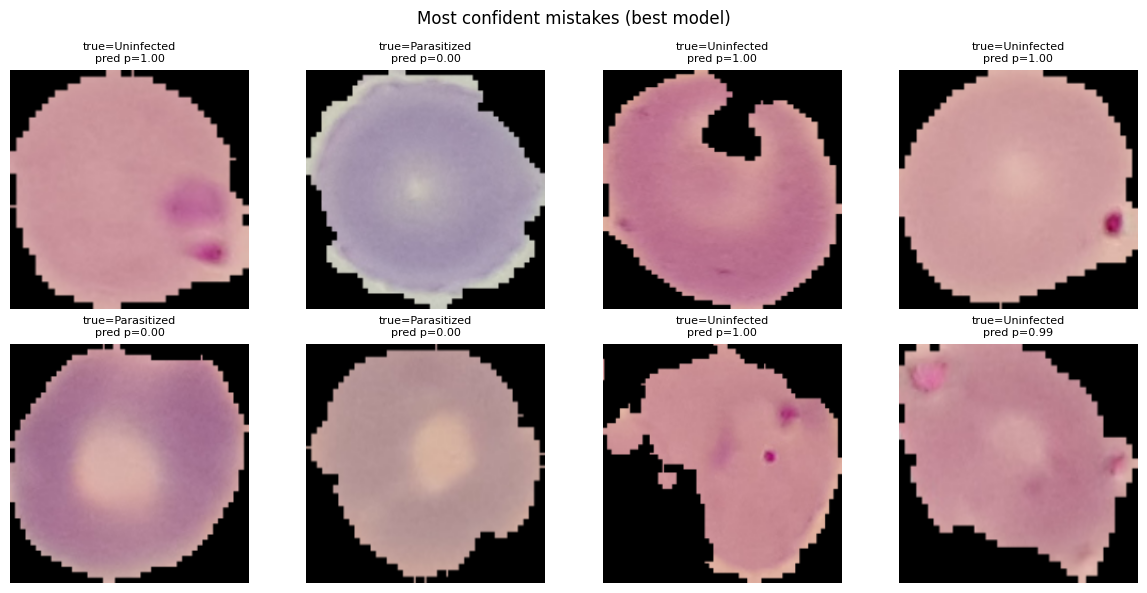

In [18]:
# Optional: inspect the worst misclassifications of the best model to support the
# error-analysis paragraph above.
order = np.argsort(np.abs(best["y_prob"] - best["y_true"]))[::-1]   # most-wrong first
worst = order[:8]
plt.figure(figsize=(12, 6))
for i, idx in enumerate(worst):
    img = tf.io.decode_png(tf.io.read_file(p_test[idx]), channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]).numpy().astype("uint8")
    plt.subplot(2, 4, i+1); plt.imshow(img); plt.axis("off")
    plt.title(f"true={CLASS_NAMES[best['y_true'][idx]]}\npred p={best['y_prob'][idx]:.2f}",
              fontsize=8)
plt.suptitle("Most confident mistakes (best model)"); plt.tight_layout(); plt.show()

## 8. Conclusion — ResNet50 (Member 4)

My best ResNet50 model was **E6_FT_top60**, using deep fine-tuning with the last 60 layers unfrozen at a learning rate of 1e-5. It reached the following on the held-out test set:

| Metric | Score |
|---|---|
| Accuracy | 0.9661 |
| Precision | ____ |
| Recall | ____ |
| F1 | 0.9660 |
| AUC | 0.9942 |

**Fine-tuning was the main driver of performance, not regularisation.** Feature extraction alone already reached an F1 of 0.95, but unfreezing layers improved it further — and unfreezing *more* layers helped: E6 (60 layers) beat E5 (30 layers), which beat the frozen baseline.

Adding augmentation and heavy dropout actually *lowered* my scores. The pretrained ImageNet features were already strong, so the extra regularisation pushed the model toward **underfitting** rather than helping it generalise.

I will complete the group ranking once everyone's results are in, comparing my **F1 of 0.9660** and **AUC of 0.9942** against the baseline CNN, improved CNN, VGG16, and MobileNetV2.

**Overall:** transfer learning with ResNet50 clearly outperformed plain feature extraction, and with deep fine-tuning it became a strong, reliable malaria-screening classifier. Its main drawback is its size, which makes it heavier to deploy than lighter models.